# 0. 환경설정

In [1]:
pip install pymysql sqlalchemy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sqlalchemy import create_engine

%pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# 1) 접속 정보 설정
USER = "root"          # MySQL 계정
PASSWORD = "123456"
HOST = "localhost"     # 도커 컨테이너를 호스트로 포워딩했으면 보통 localhost
PORT = "3400"          # docker run -p 3306:3306 했다고 가정
DB = "docker_mysql"   # 사용 중인 DB 이름

# 2) SQLAlchemy 엔진 생성
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}?charset=utf8mb4")

# 1. 데이터 불러오기

In [5]:
accounts_paymenthistory_query = """
SELECT * FROM accounts_paymenthistory
"""

payment_df = pd.read_sql(accounts_paymenthistory_query, con=engine)
payment_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [58]:
polls_question_query = """
SELECT * FROM polls_question
"""

question_df = pd.read_sql(polls_question_query, con=engine)
question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [57]:
polls_questionpiece_query = """
SELECT * FROM polls_questionpiece
"""

questionpiece_df = pd.read_sql(polls_questionpiece_query, con=engine)
questionpiece_df.head()

KeyboardInterrupt: 

In [59]:
accounts_user_query = """
SELECT * FROM accounts_user
"""

account_df = pd.read_sql(accounts_user_query, con=engine)
account_df.head()

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN
1,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12.0
2,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1.0
3,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1.0
4,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15,12.0


## 1-1. 기본 전처리

## payment_df

In [7]:
# 중복되는 created_at 제거
payment_df = payment_df.drop_duplicates(['created_at', 'user_id'])
payment_df[['created_at', 'user_id']].duplicated().sum()

np.int64(0)

---

## account_df

In [67]:
account_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677085 entries, 0 to 677084
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  677085 non-null  int64         
 1   is_superuser        677085 non-null  int64         
 2   is_staff            677085 non-null  int64         
 3   gender              677083 non-null  object        
 4   point               677085 non-null  int64         
 5   friend_id_list      677085 non-null  object        
 6   is_push_on          677085 non-null  int64         
 7   created_at          677085 non-null  datetime64[ns]
 8   block_user_id_list  677085 non-null  object        
 9   hide_user_id_list   677085 non-null  object        
 10  ban_status          677085 non-null  object        
 11  report_count        677085 non-null  int64         
 12  alarm_count         677085 non-null  int64         
 13  pending_chat        677085 no

In [62]:
for col in account_df.columns:
    print(f'{col}: {account_df[col].isnull().sum()}')

id: 0
is_superuser: 0
is_staff: 0
gender: 2
point: 0
friend_id_list: 0
is_push_on: 0
created_at: 0
block_user_id_list: 0
hide_user_id_list: 0
ban_status: 0
report_count: 0
alarm_count: 0
pending_chat: 0
pending_votes: 0
group_id: 3


In [64]:
account_df[account_df['group_id'].isnull()]

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
0,831956,1,1,None,600,"[1292473, 913158, 1488461, 1064695, 1043565, 1...",0,2023-03-29 03:44:14.047130,[],[],N,0,0,0,0,NaN
138959,995177,0,0,F,600,[],1,2023-05-08 07:25:51.737820,[],[],N,0,0,0,0,NaN
674052,1580689,0,1,None,0,[],0,2023-09-24 17:39:12.897884,[],[],N,0,0,0,0,NaN


In [ ]:
# 친구 없음
account_df[account_df['friend_id_list'] == '[]'].head()

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id
64,835173,0,0,F,600,[],1,2023-04-07 07:25:54.874222,[],[],N,0,1,0,0,94.0
5024,844850,0,0,F,310,[],1,2023-04-24 12:07:28.824298,[],[],NB,0,0,0,0,2557.0
11329,852715,0,0,M,600,[],1,2023-04-29 11:37:59.821822,[],[],N,0,1,0,0,4878.0
11710,853188,0,0,F,12692,[],1,2023-04-29 12:45:18.767122,[],[840054],W,0,0,0,0,3507.0
18425,861691,0,0,F,600,[],1,2023-04-30 16:01:18.397162,[],"[862653, 866737, 864908]",N,0,1,0,0,7181.0


In [ ]:
# N: 차단·탈퇴 이력이 없는 유저
# NB: 현재는 정상 이용 중이지만 과거에 차단 이력이 있었던 유저
# W: 탈퇴 유저
# RB: 차단 유저
account_df['ban_status'].unique()

array(['N', 'NB', 'W', 'RB'], dtype=object)

In [71]:
account_df['ban_status'].value_counts()

ban_status
N     668432
W       7855
NB       608
RB       190
Name: count, dtype: int64

# 2. eda

## 2-1. question_df, questionpiece_df 해석

**question_df**

: question_text가 같은 형식(은?)으로 끝나는 것으로 보아 유저가 직접 생성한 질문이 아닌, 서비스가 제공하는 질문으로 추측된다.

**문제점**
- 집계 기간이 8일밖에 되지 않아 분석에 활용할 수 없음

**questionpice_df**
- 한 개의 질문 세트는 10개로 구성된다.

**의문점**
1. 하나의 질문 세트 답변을 완료하면 'created_at'에는 답변한 질문의 개수가 같은 시간대로 저장된다.
    - 'created_at'을 기준으로 그룹화했을 때 10개를 초과하는 데이터가 있다. 이는 여러 명의 유저가 동시간대 답변을 했을 가능성이 있다.
2. 하나의 질문 세트는 10개로 구성되지만 10개 미만인 데이터가 있다.
    - 질문 건너뛰기를 사용해서?

**데이터 문제점**
- user_id가 없어서 누가 한 질문인지 알 수 가 없다.
- 그래서 한 세트에 질문이 10개라고 명시했지만 데이터 상으로 확인할 수 없다.


In [12]:
question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [14]:
question_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             5025 non-null   int64         
 1   question_text  5025 non-null   object        
 2   created_at     5025 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 117.9+ KB


In [48]:
question_df['created_at'].dt.strftime('%Y-%m-%d').unique()

array(['2023-03-31', '2023-04-01', '2023-05-02', '2023-05-04',
       '2023-05-11', '2023-05-15', '2023-06-02', '2023-06-06'],
      dtype=object)

---

In [ ]:
questionpiece_df.head()

,id,is_voted,created_at,question_id,is_skipped
0,998458,1,2023-04-28 12:27:22,252,0
1,998459,1,2023-04-28 12:27:22,244,0
2,998460,1,2023-04-28 12:27:22,183,0
3,998461,1,2023-04-28 12:27:22,101,0
4,998462,1,2023-04-28 12:27:22,209,0


In [16]:
questionpiece_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265476 entries, 0 to 1265475
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1265476 non-null  int64         
 1   is_voted     1265476 non-null  int64         
 2   created_at   1265476 non-null  datetime64[ns]
 3   question_id  1265476 non-null  int64         
 4   is_skipped   1265476 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 48.3 MB


In [ ]:
# 집계 기간
print(question_df['created_at'].min(), question_df['created_at'].max())
print(questionpiece_df['created_at'].min(), questionpiece_df['created_at'].max())

2023-03-31 15:22:53 2023-06-06 06:15:52
2023-04-28 12:27:22 2024-05-07 11:32:30


In [23]:
questionpiece_df['created_at'].duplicated().sum(), len(questionpiece_df)

(np.int64(1103321), 1265476)

In [24]:
questionpiece_df.groupby('created_at').size()

created_at
2023-04-28 12:27:22    10
2023-04-28 12:28:07     9
2023-04-28 12:28:38    15
2023-04-28 12:28:57     9
2023-04-28 12:29:04     2
                       ..
2024-05-05 14:06:27    10
2024-05-06 10:58:20    10
2024-05-07 00:15:00    10
2024-05-07 11:29:08    10
2024-05-07 11:32:30    10
Length: 162155, dtype: int64

In [25]:
questionpiece_df.head()

,id,is_voted,created_at,question_id,is_skipped
0,998458,1,2023-04-28 12:27:22,252,0
1,998459,1,2023-04-28 12:27:22,244,0
2,998460,1,2023-04-28 12:27:22,183,0
3,998461,1,2023-04-28 12:27:22,101,0
4,998462,1,2023-04-28 12:27:22,209,0


In [ ]:
# is_voted: 1(투표 했음), 0(투표 하지 않음)
# is_skipped: 1(건너뛰기), 0(건너뛰지 않음)
# 0, 0: 투표하지 않고, 건너 뛰지 않음
    # 근데 'created_at'이 저장됨
    # created_at의 의미가 무엇인가?
questionpiece_df.groupby(['is_voted', 'is_skipped']).size()

is_voted  is_skipped
0         0               46789
1         0             1217560
          1                1127
dtype: int64

In [ ]:
# 투표 기록 테이블 행 수: 1217558

In [ ]:
# 시간대별 is_voted, is_skipped가 0인 데이터 개수
zerozero = questionpiece_df[(questionpiece_df['is_voted'] == 0) & (questionpiece_df['is_skipped'] == 0)]
zerozero_count = zerozero.groupby('created_at').size().sort_values(ascending=False).reset_index()
zerozero_count

# is_voted, is_skipped가 0인 데이터의 'created_at'의 의미를 모르겠음

,created_at,0
0,2023-05-26 10:20:34,20
1,2023-05-29 13:53:06,20
2,2023-05-19 08:41:27,20
3,2023-05-28 16:28:49,20
4,2023-05-08 12:15:16,19
...,...,...
5311,2023-05-27 13:40:35,1
5312,2023-06-06 14:12:39,1
5313,2023-06-02 14:52:27,1
5314,2023-05-21 03:19:42,1


ping 사용량을 확인하기 전, 질문 관련 테이블을 확인할 필요가 있다. 

질문에 답변한 유저수는 4,972명으로 전체 유저(677,085명) 대비 0.7%에 불과하다.

(‘polls_questionset 테이블’의 집계 기간(2023-04-28 12:27:23 ~ 2024-05-07 11:32:30)에서 확인) 

(전체 유저수는 accounts_user)

ping 사용률이 매우 저조하다.

매출은 질문에 대한 답변으로 선택당한 친구들이 ping을 보낸 사람에 대한 힌트를 얻거나, 채팅방을 생성하는데서 발생한다.

## 2-2. 월별 질문에 답변한 유저수 및 1인당 평균 매출액

- ping 사용량 5월(90.4% 비중)에 급증
- 6월 사용량 급감. 전월 대비 6.5%
- 이후 지속적으로 하락

In [51]:
# 월별 ping 사용 유저
monthly_question = questionpiece_df.groupby(questionpiece_df['created_at'].dt.strftime('%Y-%m'))['question_id'].size().reset_index()
monthly_question['asked_user'] = monthly_question['question_id'] / 10
monthly_question

,created_at,question_id,asked_user
0,2023-04,33651,3365.1
1,2023-05,1144964,114496.4
2,2023-06,74466,7446.6
3,2023-07,6040,604.0
4,2023-08,2273,227.3
5,2023-09,2054,205.4
6,2023-10,452,45.2
7,2023-11,306,30.6
8,2023-12,555,55.5
9,2024-01,309,30.9


In [54]:
monthly_question.iloc[1, 2] / monthly_question['asked_user'].sum()

np.float64(0.9047694306332162)

In [55]:
monthly_question.iloc[2, 2] / monthly_question.iloc[1, 2]

np.float64(0.06503785271851342)

In [74]:
# 하트 가격 맵핑
heart_price = {
    'heart.200': 900,
    'heart.777': 1900,
    'heart.1000': 2900,
    'heart.4000':  9900
}

payment_df['price'] = payment_df['productId'].map(heart_price)
payment_df.head()

,id,productId,phone_type,created_at,user_id,price
0,6,heart.777,A,2023-05-13 21:28:34,1211127,1900
1,7,heart.777,A,2023-05-13 21:29:39,1151343,1900
2,8,heart.777,A,2023-05-13 21:31:33,1002147,1900
3,9,heart.777,A,2023-05-13 21:31:39,1095040,1900
4,11,heart.777,A,2023-05-13 21:34:32,1164081,1900


In [82]:
payment_df['created_at'].min(), account_df['created_at'].min()

(Timestamp('2023-05-13 21:28:34'), Timestamp('2023-03-29 03:44:14.047130'))

In [75]:
# 월별 매출액
monthly_sales = payment_df.groupby(payment_df['created_at'].dt.strftime('%Y-%m'))['price'].sum().reset_index()

monthly_sales = monthly_sales.sort_values('price', ascending=False)
monthly_sales['rate'] = monthly_sales['price'] / payment_df['price'].sum()
monthly_sales

,created_at,price,rate
0,2023-05,174733400,0.872515
1,2023-06,16168100,0.080734
2,2023-07,4223900,0.021092
3,2023-08,2765400,0.013809
4,2023-09,845500,0.004222
5,2023-10,339200,0.001694
6,2023-11,308300,0.001539
7,2023-12,280400,0.001400
8,2024-01,226000,0.001129
11,2024-04,135900,0.000679


In [84]:
# 월별 가입자 수
may_13_account_df = account_df[account_df['created_at'] >= '2023-05-13']
monthly_user= may_13_account_df.groupby(account_df['created_at'].dt.strftime('%Y-%m'))['id'].size().to_frame('user_count').reset_index()
monthly_user

,created_at,user_count
0,2023-05,336194
1,2023-06,16737
2,2023-07,1849
3,2023-08,524
4,2023-09,605
5,2023-10,409
6,2023-11,731
7,2023-12,231
8,2024-01,455
9,2024-02,255


In [99]:
# 답변한 질문
answer_user = questionpiece_df[(questionpiece_df['is_voted'] == 1) & (questionpiece_df['is_skipped'] == 0) & (questionpiece_df['created_at'] >= '2023-05-13')]
answer_user.head()

,id,is_voted,created_at,question_id,is_skipped
440798,42518434,1,2023-05-13 00:00:04,198,0
440799,42518438,1,2023-05-13 00:00:04,410,0
440800,42518442,1,2023-05-13 00:00:04,272,0
440801,42518445,1,2023-05-13 00:00:04,414,0
440802,42518450,1,2023-05-13 00:00:04,224,0


In [100]:
# 월별 답변한 질문 수
monthly_answer_question = answer_user.groupby(answer_user['created_at'].dt.strftime('%Y-%m'))['id'].size().to_frame('vote_count').reset_index()
monthly_answer_question

,created_at,vote_count
0,2023-05,715449
1,2023-06,60944
2,2023-07,3525
3,2023-08,1290
4,2023-09,756
5,2023-10,94
6,2023-11,178
7,2023-12,365
8,2024-01,145
9,2024-02,114


In [102]:
monthly_total = pd.merge(monthly_sales, monthly_user, on='created_at', how='inner')
monthly_total = pd.merge(monthly_total, monthly_answer_question, on='created_at', how='inner')
monthly_total['per_user'] = monthly_total['price'] / monthly_total['user_count']
monthly_total['per_vote'] = monthly_total['price'] / monthly_total['vote_count']
monthly_total

,created_at,price,rate,user_count,vote_count,per_user,per_vote
0,2023-05,174733400,0.872515,336194,715449,519.739793,244.229009
1,2023-06,16168100,0.080734,16737,60944,966.009440,265.294369
2,2023-07,4223900,0.021092,1849,3525,2284.424013,1198.269504
3,2023-08,2765400,0.013809,524,1290,5277.480916,2143.720930
4,2023-09,845500,0.004222,605,756,1397.520661,1118.386243
5,2023-10,339200,0.001694,409,94,829.339853,3608.510638
6,2023-11,308300,0.001539,731,178,421.751026,1732.022472
7,2023-12,280400,0.001400,231,365,1213.852814,768.219178
8,2024-01,226000,0.001129,455,145,496.703297,1558.620690
9,2024-02,108900,0.000544,255,114,427.058824,955.263158


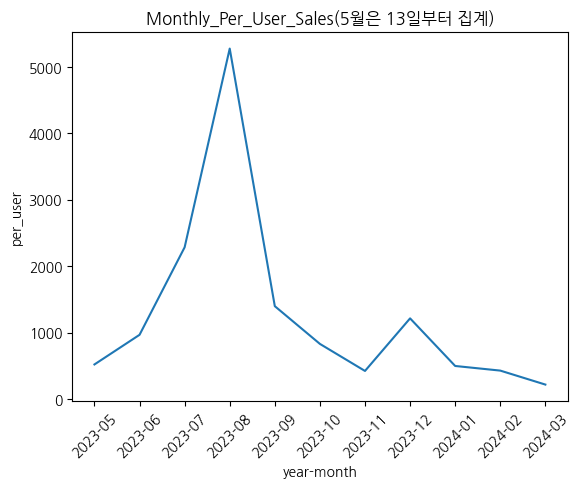

In [109]:
sns.lineplot(
    data=monthly_total,
    x='created_at',
    y='per_user'
)

plt.title('Monthly_Per_User_Sales(5월은 13일부터 집계)')
plt.xlabel('year-month')
plt.xticks(rotation=45)
plt.show()

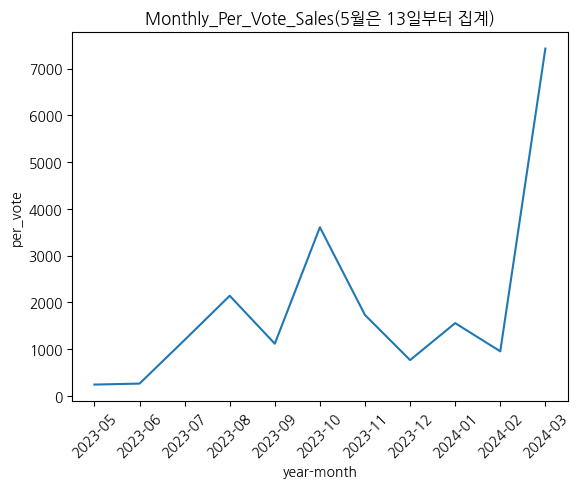

In [108]:
sns.lineplot(
    data=monthly_total,
    x='created_at',
    y='per_vote'
)

plt.title('Monthly_Per_Vote_Sales(5월은 13일부터 집계)')
plt.xlabel('year-month')
plt.xticks(rotation=45)
plt.show()

In [114]:
# 월 평균 per_vote
avg_monthly_vote_sales = round(monthly_total['per_vote'].sum() / 12, 0)
avg_monthly_vote_sales

np.float64(1752.0)

In [ ]:
payment_df.groupby('')

,id,productId,phone_type,created_at,user_id,price
0,6,heart.777,A,2023-05-13 21:28:34,1211127,1900
1,7,heart.777,A,2023-05-13 21:29:39,1151343,1900
2,8,heart.777,A,2023-05-13 21:31:33,1002147,1900
3,9,heart.777,A,2023-05-13 21:31:39,1095040,1900
4,11,heart.777,A,2023-05-13 21:34:32,1164081,1900


- 5월 매출이 전체 매출 중 가장 많은 비중을 차지하지만 인당 매출은 가장 낮은 편에 속한다.
- 매출의 주체는 질문에 답변을 하는 유저가 아닌, 질문에 대한 답변으로 선택을 받은 사람들이다.
- 따라서 인당 매출뿐만 아니라, 투표당 매출도 확인할 필요가 있다.
- 하나의 질문 세트는 10개로 구성되며 10명에게 ping이 발송된다. 
- ping을 받은 유저는 3가지 유형으로 나눌 수 있다.
    - 질문한 사람 사람을 맞추지 않는 유저
    - 하트를 결제하여 질문한 유저를 맞추는 유저
    - 무료로 받은 하트로 질문한 유저를 맞추는 유저
- 전체 사용자 중 질문을 한 4,972명을 제외한 유저는 <mark>출석체크로만 하트를 무료로 받을 수 있다.</mark>
    - 출석체크 1회 = 하트 200
    - 연속 출석시 보너스 하트를 지급
- 하트 사용
    - 초성 힌트: 초성 개수가 늘어날수록 사용해야 하는 하트가 늘어남 (1개: 하트 200, 2개: 하트 500, 3개: 하트 1000)
    - 채팅방 생성: 나를 선택한 유저를 확인하는 용도 (하트 200)